In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better-looking plots
plt.style.use('default')
sns.set_palette("husl")
fig_size = (12, 8)


df = pd.read_csv('elo_results.csv')
df["won_ratio"] = df["won"] / df["picked"]

In [3]:
display(df.head())

,base_llm,adv_llm,temp1,temp2,num_samples,latency,blog,picked,won,won_ratio
0,gemini/gemini-3-flash-preview,gemini/gemini-3.1-flash-lite,0.7,0.7,3,27.324453,# The Transformative Benefits of Meditation\n\...,10,1,0.100000
1,gemini/gemini-3.1-flash-lite,gemini/gemini-3-flash-preview,0.2,0.7,2,27.368584,# The Quiet Revolution: Unlocking the Profound...,3,3,1.000000
2,gemini/gemini-3.1-flash-lite,gemini/gemini-3.1-flash-lite,0.7,1.0,3,22.081117,# Finding Your Stillness: The Transformative P...,7,5,0.714286
3,gemini/gemini-3-flash-preview,gemini/gemini-3.1-flash-lite,0.7,0.7,3,39.522726,# The Transformative Benefits of Meditation\n\...,5,1,0.200000
4,gemini/gemini-3-flash-preview,gemini/gemini-3-flash-preview,0.2,0.2,2,32.663652,# The Life-Changing Benefits of Meditation: Fi...,5,5,1.000000


In [4]:
idea_lm_performance = df.groupby('base_llm').agg({
    'won_ratio': ['mean', 'std', 'count'],
    'latency': 'mean',
    'won_ratio': 'mean'
}).round(3)

print("Performance by Idea Language Model:")
print(idea_lm_performance)
print("\n")

Performance by Idea Language Model:
                               won_ratio  latency
base_llm                                         
gemini/gemini-3-flash-preview      0.433   33.170
gemini/gemini-3.1-flash-lite       0.857   24.725




<Figure size 1200x800 with 0 Axes>

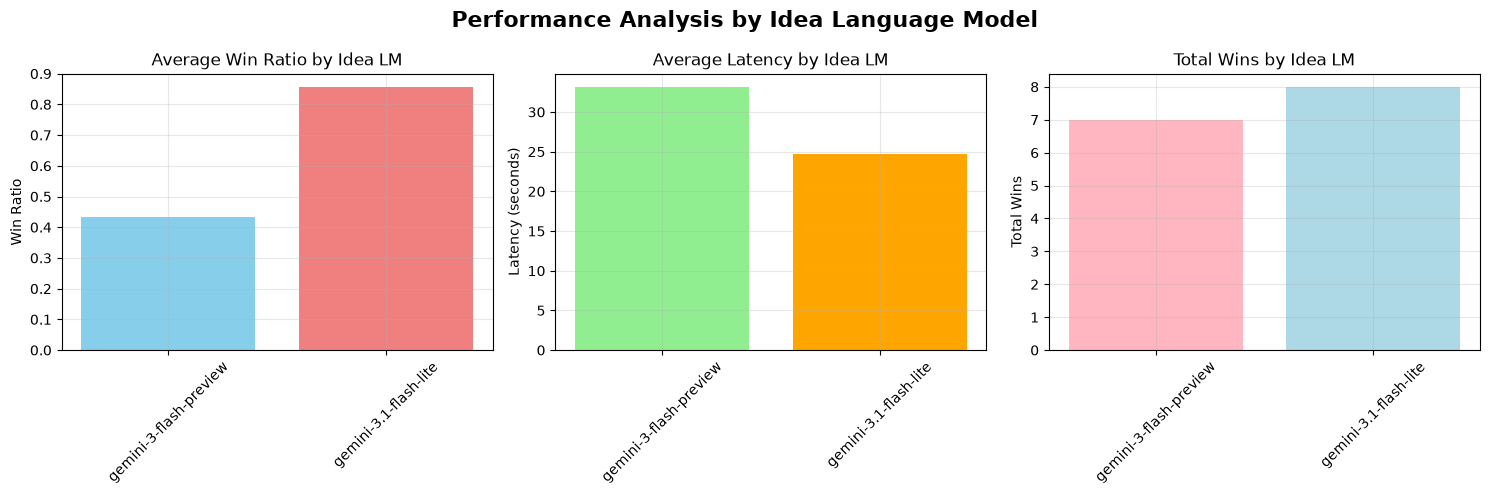

In [5]:
# Bar plot for Idea LM Performance
plt.figure(figsize=fig_size)

# Create subplot layout
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Performance Analysis by Idea Language Model', fontsize=16, fontweight='bold')

# Plot 1: Average Won Ratio
idea_lm_won_ratio = df.groupby('base_llm')['won_ratio'].mean()
axes[0].bar(range(len(idea_lm_won_ratio)), idea_lm_won_ratio.values, 
               color=['skyblue', 'lightcoral'])
axes[0].set_title('Average Win Ratio by Idea LM')
axes[0].set_ylabel('Win Ratio')
axes[0].set_xticks(range(len(idea_lm_won_ratio)))
axes[0].set_xticklabels([lm.split('/')[-1] for lm in idea_lm_won_ratio.index], rotation=45)
axes[0].grid(True, alpha=0.3)

# Plot 2: Average Latency
idea_lm_latency = df.groupby('base_llm')['latency'].mean()
axes[1].bar(range(len(idea_lm_latency)), idea_lm_latency.values,
               color=['lightgreen', 'orange'])
axes[1].set_title('Average Latency by Idea LM')
axes[1].set_ylabel('Latency (seconds)')
axes[1].set_xticks(range(len(idea_lm_latency)))
axes[1].set_xticklabels([lm.split('/')[-1] for lm in idea_lm_latency.index], rotation=45)
axes[1].grid(True, alpha=0.3)

# Plot 4: Total Wins
idea_lm_won = df.groupby('base_llm')['won'].sum()
axes[2].bar(range(len(idea_lm_won)), idea_lm_won.values,
               color=['lightpink', 'lightblue'])
axes[2].set_title('Total Wins by Idea LM')
axes[2].set_ylabel('Total Wins')
axes[2].set_xticks(range(len(idea_lm_won)))
axes[2].set_xticklabels([lm.split('/')[-1] for lm in idea_lm_won.index], rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Performance by Temperature:
      won_ratio             latency picked won
           mean   std count    mean    sum sum
temp1                                         
0.2       1.000  0.00     2  30.016      8   8
0.7       0.338  0.33     3  29.643     22   7


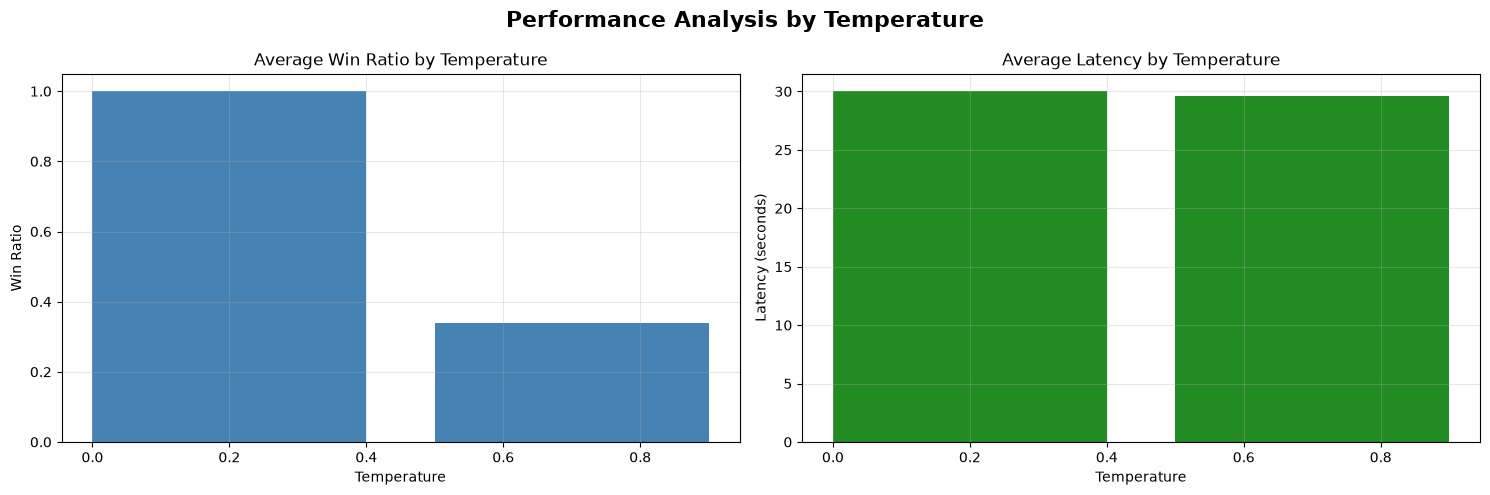

In [7]:
temperature_performance = df.groupby('temp1').agg({
    'won_ratio': ['mean', 'std', 'count'],
    'latency': 'mean',
    'picked': 'sum',
    'won': 'sum'
}).round(3)

print("Performance by Temperature:")
print(temperature_performance)

# Plot Temperature Analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Performance Analysis by Temperature', fontsize=16, fontweight='bold')

# Plot 1: Win Ratio by Temperature
temp_won_ratio = df.groupby('temp1')['won_ratio'].mean()
axes[0].bar(temp_won_ratio.index, temp_won_ratio.values, color='steelblue', width=0.4)
axes[0].set_title('Average Win Ratio by Temperature')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Win Ratio')
axes[0].grid(True, alpha=0.3)

# Plot 2: Latency by Temperature
temp_latency = df.groupby('temp1')['latency'].mean()
axes[1].bar(temp_latency.index, temp_latency.values, color='forestgreen', width=0.4)
axes[1].set_title('Average Latency by Temperature')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Latency (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Performance by Temperature:
      won_ratio              latency picked won
           mean    std count    mean    sum sum
temp2                                          
0.2       1.000    NaN     1  32.664      5   5
0.7       0.433  0.493     3  31.405     18   5
1.0       0.714    NaN     1  22.081      7   5


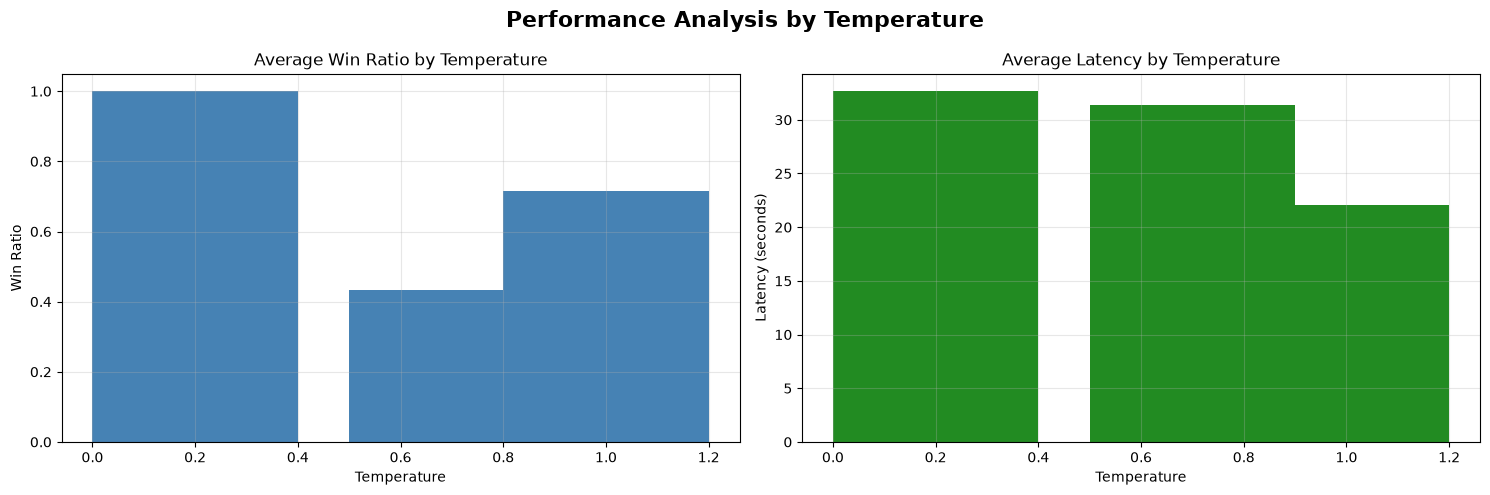

In [9]:
temperature_performance = df.groupby('temp2').agg({
    'won_ratio': ['mean', 'std', 'count'],
    'latency': 'mean',
    'picked': 'sum',
    'won': 'sum'
}).round(3)

print("Performance by Temperature:")
print(temperature_performance)

# Plot Temperature Analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Performance Analysis by Temperature', fontsize=16, fontweight='bold')

# Plot 1: Win Ratio by Temperature
temp_won_ratio = df.groupby('temp2')['won_ratio'].mean()
axes[0].bar(temp_won_ratio.index, temp_won_ratio.values, color='steelblue', width=0.4)
axes[0].set_title('Average Win Ratio by Temperature')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Win Ratio')
axes[0].grid(True, alpha=0.3)

# Plot 2: Latency by Temperature
temp_latency = df.groupby('temp2')['latency'].mean()
axes[1].bar(temp_latency.index, temp_latency.values, color='forestgreen', width=0.4)
axes[1].set_title('Average Latency by Temperature')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Latency (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()